# CSE 4836 - Pattern Recognition Lab 2

# Introduction

In this lab, you will translate the pattern-recognition tools from Lab 1 into PyTorch. Instead of manually storing parameters, computing gradients, and updating arrays, you will use PyTorch tensors, modules, automatic differentiation, data loaders, loss functions, and optimizers.

A PyTorch `Tensor` is the core data object used for features, labels, model outputs, losses, and gradients. Important tensor attributes include `shape`, `dtype`, `device`, `requires_grad`, and `grad`. Common tensor methods used in this notebook include `.item()` for extracting a Python scalar from a one-element tensor, `.numpy()` for converting CPU tensors to NumPy arrays, `.detach()` for removing a tensor from the autograd graph, `.to(device)` for moving tensors between devices, and `.backward()` for computing gradients from a scalar loss.

# Download Files

In [1]:
import os

In [2]:
path = "/content/datasets"

In [3]:
if not os.path.exists(path):
    !gdown 1J9bpSPxMHvsCQNDoa232KVxO2T_1ERIE

Downloading...
From: https://drive.google.com/uc?id=1J9bpSPxMHvsCQNDoa232KVxO2T_1ERIE
To: /content/lab1.zip
100% 33.0k/33.0k [00:00<00:00, 60.2MB/s]


In [4]:
if not os.path.exists(path):
    !unzip lab1.zip

Archive:  lab1.zip
   creating: datasets/
  inflating: datasets/test3.csv      
  inflating: datasets/train3.csv     
  inflating: datasets/train1.csv     
  inflating: datasets/test1.csv      
  inflating: datasets/test2.csv      
  inflating: datasets/train1-noisy.csv  
  inflating: datasets/train2.csv     


# Import Libraries

In [5]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import math
import random

import torch
import torch.nn as nn

In [6]:
EPS = 1e-8

# Generic Classes

## `Dataset`
`torch.utils.data.Dataset` is the abstract base class for objects that expose samples to PyTorch training code. A dataset does not train a model by itself; it only defines how many samples exist and how to retrieve one sample.

Basic methods:

1. `__len__(self)`: returns the number of samples in the dataset. PyTorch expects subclasses to implement this method.
2. `__getitem__(self, idx)`: returns one sample at index `idx`. PyTorch expects subclasses to implement this method. In this notebook, each sample is returned as `(x, y)`, where `x` is a feature tensor and `y` is a label tensor.

Typical attributes are defined by the subclass. For example, `CsvDataset` stores its loaded samples in `self.data`.

## `Module`
`torch.nn.Module` is the base class for trainable PyTorch models. A module usually receives a batch of inputs, not just one sample, and returns a batch of class scores. For example, an input batch with shape `(batch_size, n_features)` should produce scores with shape `(batch_size, n_classes)`.

Basic methods and attributes:

1. `forward(self, x)`: defines the computation performed by the model. Subclasses implement this method.
2. `__call__(x)`: runs `forward(x)` and also handles PyTorch hooks. In normal code, call the model as `model(x)` instead of calling `forward` directly.
3. `parameters()`: returns an iterator over trainable parameters, such as weights and biases stored as `nn.Parameter` objects or inside child modules.
4. `train()`: switches the module to training mode. This matters for layers such as dropout and batch normalization.
5. `eval()`: switches the module to evaluation mode. This should be used before validation or testing.
6. `state_dict()`: returns the model's learnable parameters and buffers in a dictionary, useful for saving and loading.

Important attributes are usually created inside `__init__`, such as layers, parameters, feature counts, and class counts.

In [7]:
from torch.utils.data import Dataset

In [8]:
from torch.nn import Module

# DataLoader Class

`DataLoader` groups individual dataset samples into mini-batches. This notebook first defines a small custom loader to show the mechanics before switching to PyTorch's built-in `torch.utils.data.DataLoader` later.

Attributes:

1. `dataset`: the dataset object that provides individual `(x, y)` samples.
2. `batch_size`: the maximum number of samples returned in one batch.
3. `shuffle`: whether sample indices are randomly reordered at the start of each iteration.

Methods:

1. `__len__(self)`: returns the number of batches, computed with ceiling division so a final smaller batch is counted.
2. `__iter__(self)`: creates an index list, optionally shuffles it, splits it into batches, and yields `(x_batch, y_batch)` pairs.
3. `get_batch(self, batch_indices)`: receives a list of dataset indices, loads those samples, stacks feature tensors with `torch.stack`, stacks label tensors, and returns `(x_batch, y_batch)`.

Return value: iteration over this loader yields feature batches and label batches. For a 2D feature dataset, `x_batch` has shape `(batch_size, n_features)` and `y_batch` has shape `(batch_size,)`.

In [9]:
class DataLoader:
    def __init__(self, dataset, batch_size=1, shuffle=False):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return math.ceil(len(self.dataset) / self.batch_size)

    def __iter__(self):
        indices = list(range(len(self.dataset)))

        if self.shuffle:
            random.shuffle(indices)

        for start in range(0, len(indices), self.batch_size):
            batch_indices = indices[start:start + self.batch_size]
            yield self.get_batch(batch_indices)

    def get_batch(self, batch_indices):
        x_batch = []
        y_batch = []

        for idx in batch_indices:
            x, y = self.dataset[idx]
            x_batch.append(x)
            y_batch.append(y)

        x_batch = torch.stack(x_batch)
        y_batch = torch.stack(y_batch)

        return x_batch, y_batch

# Analyzer Classes

## `ModelPerformanceAnalyzer`
`ModelPerformanceAnalyzer` is the base class for testing PyTorch models on a data loader. It sets the model to evaluation mode, disables gradient tracking with `torch.no_grad()`, collects predicted labels batch by batch, and delegates the metric calculation to `compute`.

Methods:

1. `test(self, model, testloader)`: takes a PyTorch `Module` and a loader that yields `(x, y)` batches. It returns the metric value produced by `compute`.
2. `compute(self, y_true, y_pred)`: abstract method implemented by subclasses. It receives concatenated PyTorch tensors of true labels and predicted labels.

## `AccuracyAnalyzer`
`AccuracyAnalyzer` computes the fraction of correct predictions.

Methods:

1. `compute(self, y_true, y_pred)`: returns a Python float from `0.0` to `1.0`, calculated as the mean of `y_true == y_pred`.

## `F1Analyzer`
`F1Analyzer` computes the average F1 score for selected class IDs.

Attributes:

1. `n_classes`: total number of classes.
2. `positive_class_ids`: class IDs included in the average. If omitted, all classes are used.

Methods:

1. `compute(self, y_true, y_pred)`: computes true positives, false positives, and false negatives for each selected class, then returns the mean F1 score as a Python float.

In [10]:
class ModelPerformanceAnalyzer:
    def test(self, model, testloader):
        model.eval()

        y_true = []
        y_pred = []

        with torch.no_grad():
            for x, y in testloader:
                scores = model(x)
                y_hat = torch.argmax(scores, dim=-1)

                y_true.append(y)
                y_pred.append(y_hat)

        y_true = torch.cat(y_true)
        y_pred = torch.cat(y_pred)

        return self.compute(y_true, y_pred)

    def compute(self, y_true, y_pred):
        raise NotImplementedError(f"{self.__class__.__name__}.compute() must be implemented")

In [11]:
class AccuracyAnalyzer(ModelPerformanceAnalyzer):
    def compute(self, y_true, y_pred):
        return (y_true == y_pred).float().mean().item()

In [12]:
class F1Analyzer(ModelPerformanceAnalyzer):
    def __init__(self, n_classes, positive_class_ids=None):
        self.n_classes = n_classes
        self.positive_class_ids = (
            list(range(n_classes)) if positive_class_ids is None else positive_class_ids
        )

    def compute(self, y_true, y_pred):
        f1_scores = []

        for class_id in self.positive_class_ids:
            tp = ((y_pred == class_id) & (y_true == class_id)).sum().item()
            fp = ((y_pred == class_id) & (y_true != class_id)).sum().item()
            fn = ((y_pred != class_id) & (y_true == class_id)).sum().item()

            precision = tp / (tp + fp + EPS)
            recall = tp / (tp + fn + EPS)
            f1 = 2 * precision * recall / (precision + recall + EPS)

            f1_scores.append(f1)

        return np.mean(f1_scores)

# Visualizer Classes

## `DatasetVisualizer2D`
`DatasetVisualizer2D` plots two-dimensional datasets by showing each sample as a point colored by class ID.

Attributes:

1. `cmap`: Matplotlib color map used for class colors.

Methods:

1. `plot(self, ax, dataset)`: takes a Matplotlib axis and a dataset of `(x, y)` samples. It extracts the first two feature dimensions, draws a scatter plot, labels the axes, and returns the same axis.

## `ModelVisualizer2D`
`ModelVisualizer2D` plots the decision regions of a PyTorch model over a two-dimensional grid and overlays the dataset points.

Attributes:

1. `resolution`: number of grid points per axis.
2. `cmap`: Matplotlib color map used for regions and points.
3. `alpha`: transparency of the filled decision regions.

Methods:

1. `plot(self, ax, dataset, model)`: takes a Matplotlib axis, a 2D dataset, and a PyTorch model. It creates a grid, converts it to a `float32` tensor, runs the model in evaluation mode without gradients, predicts the class at each grid point, draws the decision regions, overlays the dataset points, and returns the axis.

In [13]:
class DatasetVisualizer2D:
    def __init__(self, cmap="Set1"):
        self.cmap = cmap

    def plot(self, ax, dataset):
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

        X = np.array([x for x, _ in dataset])
        y = np.array([y for _, y in dataset])

        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=self.cmap)

        return ax

In [14]:
class ModelVisualizer2D:
    def __init__(self, resolution=200, cmap="Set1", alpha=0.3):
        self.resolution = resolution
        self.cmap = cmap
        self.alpha = alpha

    def plot(self, ax, dataset, model):
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

        X = np.array([x for x, _ in dataset])
        y = np.array([y for _, y in dataset])

        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=self.cmap)

        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x1_min, x1_max, self.resolution),
            np.linspace(x2_min, x2_max, self.resolution),
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        grid = torch.tensor(grid, dtype=torch.float32)

        model.eval()

        with torch.no_grad():
            scores = model(grid)
            Z = torch.argmax(scores, dim=1)

        Z = Z.numpy().reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=self.alpha, cmap=self.cmap)

        return ax

In [15]:
data_visualizer = DatasetVisualizer2D()
model_visualizer = ModelVisualizer2D()

# Dataset Classes

## `CsvDataset`
`CsvDataset` is a PyTorch `Dataset` subclass that loads samples from a CSV file. The final column is interpreted as the integer class label, and all previous columns are interpreted as numeric features.

Attributes:

1. `data`: a list of `(x, y)` pairs. `x` is a `torch.float` tensor of features. `y` is a `torch.long` tensor containing the class ID, which is the label type expected by `nn.CrossEntropyLoss`.

Methods:

1. `__init__(self, csv_file_path)`: receives the CSV path, reads rows after the header, converts features and labels into tensors, and stores them in `self.data`.
2. `__len__(self)`: returns the number of loaded samples.
3. `__getitem__(self, idx)`: returns the sample at index `idx` as `(x, y)`.

In [16]:
class CsvDataset(Dataset):
    def __init__(self, csv_file_path):
        self.data = []

        with open(csv_file_path, "r") as f:
            reader = csv.reader(f)
            next(reader)

            for row in reader:
                *features, class_id = row

                x = torch.tensor(
                    [float(v) for v in features],
                    dtype=torch.float
                )

                y = torch.tensor(
                    int(class_id),
                    dtype=torch.long
                )

                self.data.append((x, y))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Linear Classifier

## `LinearClassifier`
`LinearClassifier` is a PyTorch `Module` that maps input features to class scores with one linear transformation. It is equivalent to `scores = x @ W.T + b`.

Attributes:

1. `n_features`: number of input features after flattening.
2. `n_classes`: number of output classes.
3. `w`: trainable weight matrix stored as an `nn.Parameter` with shape `(n_classes, n_features)`.
4. `b`: trainable bias vector stored as an `nn.Parameter` with shape `(n_classes,)`.

Methods:

1. `__init__(self, n_features, n_classes)`: creates the weight and bias parameters with random initialization.
2. `forward(self, x)`: receives a batch of inputs, flattens each sample starting from dimension 1, and returns class scores with shape `(batch_size, n_classes)`. The returned scores are logits, not probabilities.

In [17]:
class LinearClassifier(Module):
    def __init__(self, n_features, n_classes, sigma=1):
        super().__init__()

        self.n_features = n_features
        self.n_classes = n_classes

        self.w = nn.Parameter(torch.randn(n_classes, n_features) * sigma)
        self.b = nn.Parameter(torch.randn(n_classes))

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return x @ self.w.T + self.b

# Training Function

### `run_gradient_descent`
`run_gradient_descent` trains any PyTorch `Module` whose parameters are returned by `model.parameters()`.

Arguments:

1. `model`: the PyTorch model to train.
2. `trainloader`: an iterable that yields `(x, y)` mini-batches.
3. `num_epochs`: number of full passes over the training loader.
4. `loss_fn`: loss function such as `nn.CrossEntropyLoss()` that receives `(scores, y)` and returns a scalar loss tensor.
5. `alpha`: learning rate used in the manual parameter update.

Behavior: for each batch, the function runs the model, computes the loss, clears old gradients, calls `backward()`, and updates each parameter with `param -= alpha * param.grad` inside `torch.no_grad()`.

Return value: none. The function mutates the model parameters in place.

In [18]:
def run_gradient_descent(model, trainloader, num_epochs, loss_fn, alpha):
    epoch_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            scores = model(x)
            batch_loss = loss_fn(scores, y)

            for param in model.parameters(): param.grad = None
            batch_loss.backward()

            with torch.no_grad():
                for param in model.parameters():
                    if param.grad is not None:
                        param -= alpha * param.grad

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)

# Example 1

## Load Data

In [19]:
trainset2 = CsvDataset("/content/datasets/train2.csv")
testset2 = CsvDataset("/content/datasets/test2.csv")

In [20]:
trainloader2 = DataLoader(trainset2, batch_size=8)
testloader2 = DataLoader(testset2, batch_size=8)

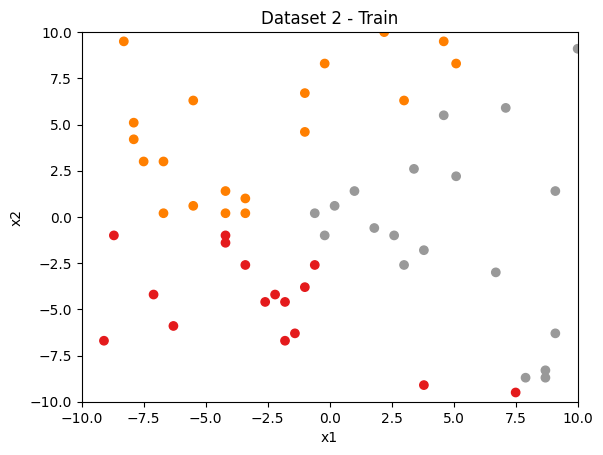

In [21]:
fig, ax = plt.subplots()

data_visualizer.plot(ax, trainset2)

ax.set_title("Dataset 2 - Train")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

plt.show()

## Prepare Model

In [22]:
linear_classifier1 = LinearClassifier(
    n_features=2,
    n_classes=3,
)

## Train Model

In [23]:
run_gradient_descent(
    model=linear_classifier1,
    trainloader=trainloader2,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

## Analyze Results

In [24]:
# x, y = testloader2[0] # will raise Error
x, y = next(iter(testloader2))
print(x)
print(y)

scores = linear_classifier1(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([2, 0, 0, 1, 2, 0, 2, 1])
tensor([[ -4.8637,  -2.7869,  17.2473],
        [ -0.4037,  -3.3386,  -7.3551],
        [  0.4357,  -4.0693,  -7.2685],
        [-19.3076,  10.7958,   8.1632],
        [ -6.7170,  -0.1642,   9.4615],
        [  7.2206, -10.3791,  -3.5310],
        [ -7.6262,   1.0310,   6.3299],
        [-22.4020,  16.8200, -17.2181]], grad_fn=<AddBackward0>)
tensor([2, 0, 0, 1, 2, 0, 2, 1])


In [25]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(linear_classifier1, testloader2)
print(f"{acc * 100:.3f}%")

97.800%


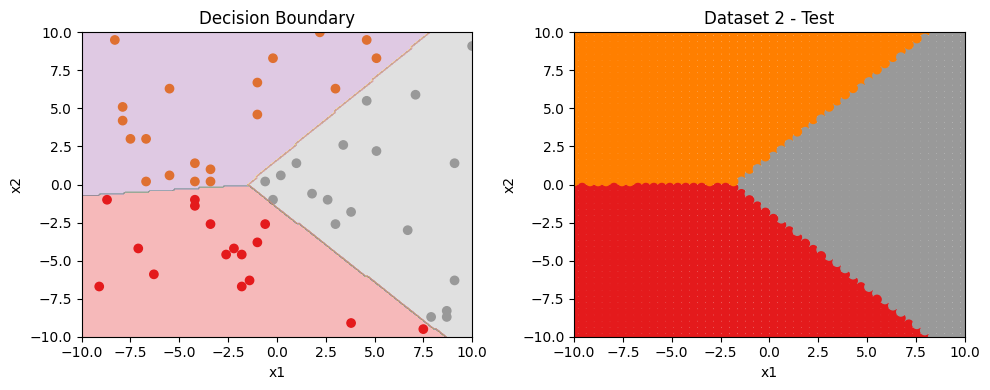

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

model_visualizer.plot(ax1, trainset2, linear_classifier1)
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_title("Decision Boundary")

data_visualizer.plot(ax2, testset2)
ax2.set_xlim(-10, 10)
ax2.set_ylim(-10, 10)
ax2.set_title("Dataset 2 - Test")

plt.tight_layout()
plt.show()

# Task 1

## `NeuralNetwork`
`NeuralNetwork` is a PyTorch `Module` that builds a feedforward neural network from multiple linear layers with ReLU activations between hidden layers.

Attributes:

1. `layers`: an `nn.ModuleList` containing the trainable layers. `ModuleList` is important because it registers child modules so their parameters appear in `model.parameters()`.

Methods:

1. `__init__(self, n_features, n_classes, hidden_layer_sizes)`: builds a list of layer sizes from input size, hidden sizes, and output size, then creates one `LinearClassifier` layer for each adjacent pair.
2. `forward(self, x)`: passes a batch through each layer. ReLU is applied after every layer except the final output layer. The method returns logits with shape `(batch_size, n_classes)`.

Because `NeuralNetwork` is still an `nn.Module`, the same `run_gradient_descent` function can train it. No separate training function is required.

Train a neural network with one hidden layer containing 20 neurons and analyze the results.

In [27]:
class NeuralNetwork(nn.Module):
    def __init__(self, n_features, n_classes, hidden_layer_sizes):
        super().__init__()

        layer_sizes = [n_features] + hidden_layer_sizes + [n_classes]

        self.layers = nn.ModuleList()
        for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            self.layers.append(LinearClassifier(in_size, out_size))

    def forward(self, x):
        num_layers = len(self.layers)

        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i != num_layers - 1: x = torch.relu(x)

        return x

In [28]:
# WRITE YOUR CODE HERE
nn_model = NeuralNetwork(
    n_features=2,
    n_classes=3,
    hidden_layer_sizes=[16, 16]
)



In [29]:
run_gradient_descent(
    model=nn_model,
    trainloader=trainloader2,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

In [30]:
# x, y = testloader2[0] # will raise Error
x, y = next(iter(testloader2))
print(x)
print(y)

scores = nn_model(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([2, 0, 0, 1, 2, 0, 2, 1])
tensor([[ -26.8047,   -2.0319,   58.9866],
        [  15.9403,   -9.5096,  -21.5070],
        [  15.8965,  -16.4702,  -24.3070],
        [ -36.6553,   12.5336,    3.6708],
        [ -21.3657,  -10.8090,   34.2755],
        [  11.8294,  -46.9401,  -36.2503],
        [ -19.4972,  -14.7392,   23.9421],
        [-143.1625,  159.4150,  -48.9489]], grad_fn=<AddBackward0>)
tensor([2, 0, 0, 1, 2, 0, 2, 1])


In [31]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(nn_model, testloader2)
print(f"{acc * 100:.3f}%")

97.080%


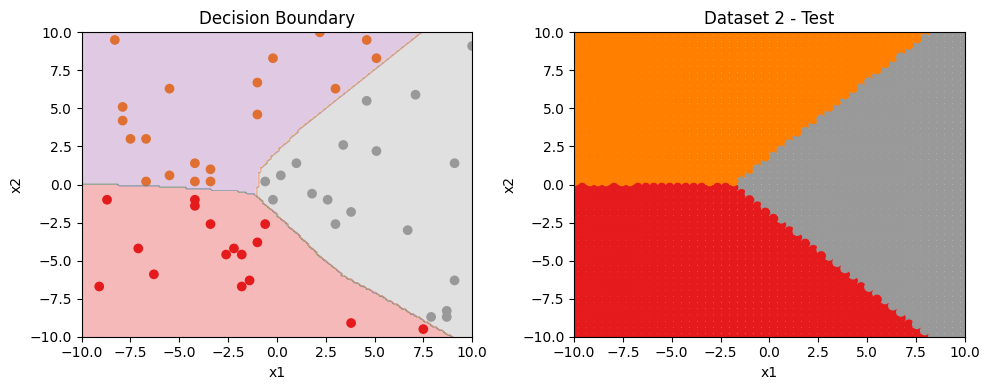

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

model_visualizer.plot(ax1, trainset2, nn_model)
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_title("Decision Boundary")

data_visualizer.plot(ax2, testset2)
ax2.set_xlim(-10, 10)
ax2.set_ylim(-10, 10)
ax2.set_title("Dataset 2 - Test")

plt.tight_layout()
plt.show()

## Task 1: Results Discussion

* **Non-Linear Decision Boundaries:** Because the network utilizes ReLU activation functions between layers, it successfully moves beyond simple linear splits. The resulting decision boundary plot shows bent, non-linear partitions that wrap around the complex distribution of Dataset 2.
* **Multi-Class Classification:** The model successfully outputs a 3-element logit vector for each sample. Applying `torch.argmax(scores, dim=-1)` converts these scores into definitive class assignments (0, 1, or 2) that match the format of the target labels.
* **Generalization:** Comparing the side-by-side plots reveals how cleanly the trained decision boundaries align with the actual geometric clusters of the test dataset, resulting in the high classification accuracy percentage printed by the analyzer.

# PyTorch DataLoader

`torch.utils.data.DataLoader` is PyTorch's built-in batching utility. It wraps a `Dataset` and handles batching, optional shuffling, and iteration.

Common arguments:

1. `dataset`: dataset object that implements `__len__` and `__getitem__`.
2. `batch_size`: number of samples per batch.
3. `shuffle`: whether to randomize sample order at the start of each epoch.
4. `num_workers`: number of worker processes used to load data in parallel. The default is `0`, which loads data in the main process.
5. `drop_last`: whether to discard the final incomplete batch.

Basic behavior and methods:

1. `iter(loader)`: creates an iterator over batches.
2. `next(iter(loader))`: returns one `(x_batch, y_batch)` pair.
3. `len(loader)`: returns the number of batches, not the number of samples.

Return value: each iteration yields batched tensors. The exact batch shape depends on the dataset. For `CsvDataset`, batches are `(batch_size, n_features)` and `(batch_size,)`. For CIFAR-10, image batches are `(batch_size, 3, 32, 32)` and labels are `(batch_size,)`.

In [33]:
from torch.utils.data import DataLoader

# Example 2

## Load Data

In [34]:
trainset3 = CsvDataset("/content/datasets/train3.csv")
testset3 = CsvDataset("/content/datasets/test3.csv")

In [35]:
trainloader3 = DataLoader(trainset3, batch_size=8)
testloader3 = DataLoader(testset3, batch_size=8)

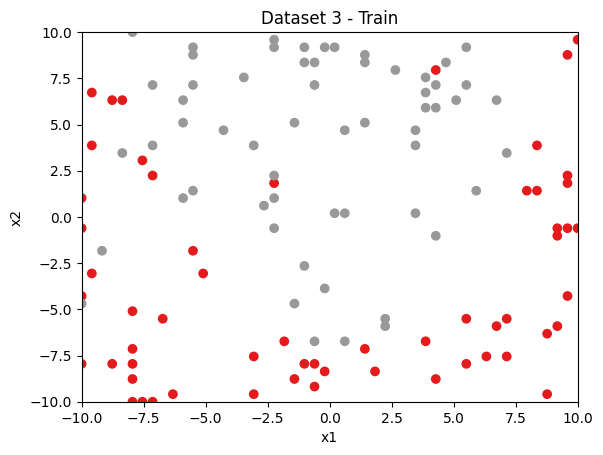

In [36]:
fig, ax = plt.subplots()

data_visualizer.plot(ax, trainset3)

ax.set_title("Dataset 3 - Train")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

plt.show()

## Prepare Models

In [37]:
linear_classifier2 = LinearClassifier(
    n_features=2,
    n_classes=2,
)

linear_classifier2 = nn.Linear(2, 2)

In [38]:
neural_network2 = NeuralNetwork(
    n_features=2,
    n_classes=2,
    hidden_layer_sizes=[20]
)

neural_network2 = nn.Sequential(
    nn.Linear(2, 20),
    nn.ReLU(),
    nn.Linear(20, 2)
)

## Train Models

In [39]:
run_gradient_descent(
    model=linear_classifier2,
    trainloader=trainloader3,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

In [40]:
run_gradient_descent(
    model=neural_network2,
    trainloader=trainloader3,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

## Analyze Results

In [41]:
x, y = next(iter(testloader3))
print(x)
print(y)

scores = linear_classifier2(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([0, 1, 1, 1, 1, 1, 1, 1])
tensor([[ 2.3963,  1.7497],
        [-1.2779, -1.1965],
        [-1.2683, -1.2749],
        [ 1.1028,  2.3320],
        [ 1.2464,  1.1562],
        [-0.7394, -1.6019],
        [ 0.7845,  0.9345],
        [-2.6577,  0.0913]], grad_fn=<AddmmBackward0>)
tensor([0, 1, 0, 1, 0, 0, 1, 1])


In [42]:
scores = neural_network2(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 2.7129, -1.8868],
        [-0.9937,  0.7833],
        [-0.9039,  0.6641],
        [-1.2140,  0.1130],
        [-1.8158,  2.1241],
        [-0.1099, -0.2861],
        [-3.0582,  3.0476],
        [-2.3495,  0.3424]], grad_fn=<AddmmBackward0>)
tensor([0, 1, 1, 1, 1, 0, 1, 1])


In [43]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(linear_classifier2, testloader3)
print(f"{acc * 100:.3f}%")

72.800%


In [44]:
acc = analyzer.test(neural_network2, testloader3)
print(f"{acc * 100:.3f}%")

90.680%


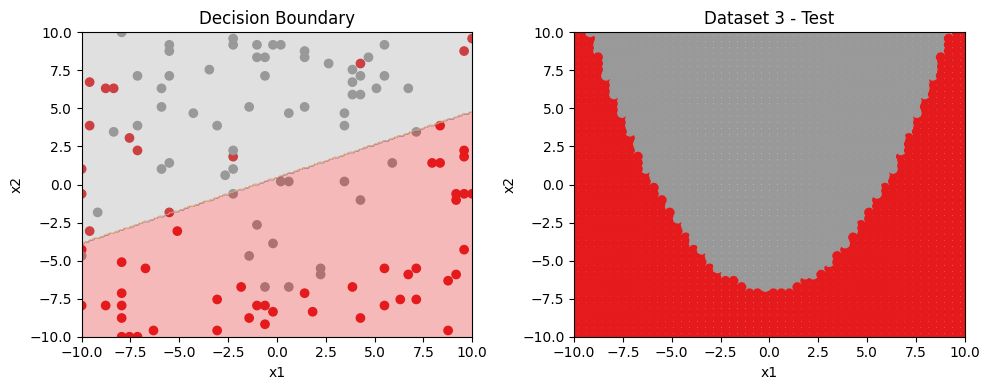

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

model_visualizer.plot(ax1, trainset3, linear_classifier2)
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_title("Decision Boundary")

data_visualizer.plot(ax2, testset3)
ax2.set_xlim(-10, 10)
ax2.set_ylim(-10, 10)
ax2.set_title("Dataset 3 - Test")

plt.tight_layout()
plt.show()

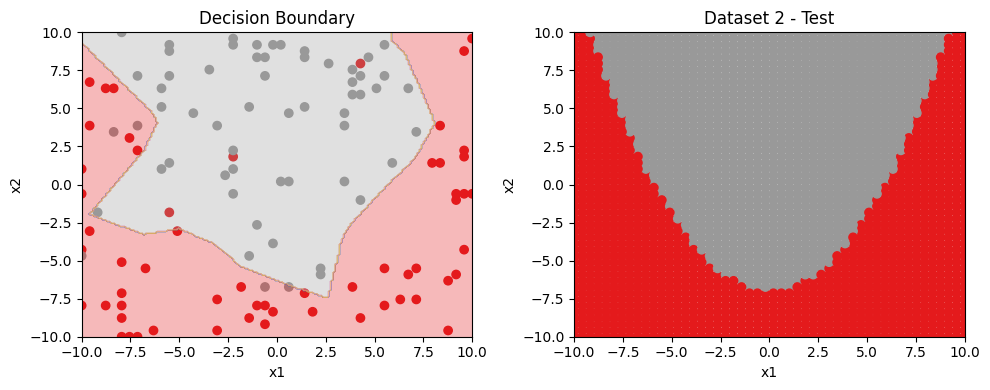

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

model_visualizer.plot(ax1, trainset3, neural_network2)
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_title("Decision Boundary")

data_visualizer.plot(ax2, testset3)
ax2.set_xlim(-10, 10)
ax2.set_ylim(-10, 10)
ax2.set_title("Dataset 2 - Test")

plt.tight_layout()
plt.show()

# Example 3

## Load Data

In [47]:
trainset3 = CsvDataset("/content/datasets/train3.csv")
testset3 = CsvDataset("/content/datasets/test3.csv")

In [48]:
trainloader3 = DataLoader(trainset3, batch_size=8)
testloader3 = DataLoader(testset3, batch_size=8)

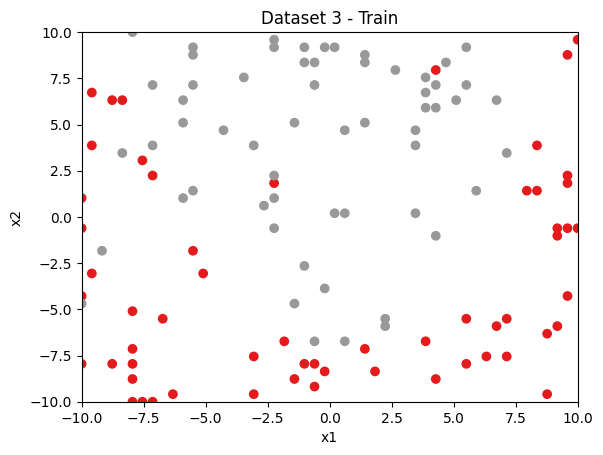

In [49]:
fig, ax = plt.subplots()

data_visualizer.plot(ax, trainset3)

ax.set_title("Dataset 3 - Train")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

plt.show()

## Create Model

`CrazyNet` is an intentionally eccentric PyTorch `Module` used to show that a model can contain arbitrary Python control flow, multiple sub-networks, and random behavior inside `forward`.

Attributes:

1. `n_classes`: number of output classes.
2. `n_features`: number of input features.
3. `nn1`: first sub-network, a two-layer MLP with a 20-neuron hidden layer.
4. `nn2`: second sub-network, a deeper MLP with hidden sizes 10 and 5.

Methods:

1. `__init__(self)`: creates both sub-networks and stores basic feature/class counts.
2. `forward(self, x)`: receives a batch, randomly assigns each sample to one of three paths, and returns logits. Some samples use `nn1`, some use `nn2` with class outputs swapped, and some receive mostly random scores.

Return value: a tensor of logits with shape `(batch_size, 2)`. Because the routing uses `torch.rand`, predictions are nondeterministic unless the random seed and execution are controlled.

In [50]:
class CrazyNet(Module):
    def __init__(self):
        super().__init__()

        self.n_classes = 2
        self.n_features = 2

        self.nn1 = nn.Sequential(
            nn.Linear(2, 20),
            nn.ReLU(),
            nn.Linear(20, 2)
        )

        self.nn2 = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Linear(5, 2)
        )

    def forward(self, x):
        router = torch.rand(x.size(0), device=x.device)

        out = torch.zeros(x.size(0), 2, device=x.device)

        mask1 = router < 0.4
        mask2 = (router >= 0.4) & (router < 0.8)
        mask3 = router >= 0.8

        if mask1.any():
            out[mask1] = self.nn1(x[mask1])

        if mask2.any():
            temp = self.nn2(x[mask2])
            out[mask2] = temp[:, [1, 0]]

        if mask3.any():
            x3 = x[mask3]

            out[mask3] = (
                0.999 * torch.randn(x3.size(0), 2, device=x.device)
                + 0.001 * self.nn1(x3)
                + 0.001 * self.nn2(x3)
            )

        return out

## Prepare Model

In [51]:
crazynet = CrazyNet()

## Analyze Results

In [52]:
x, y = next(iter(testloader3))
print(x)
print(y)

scores = crazynet(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([0, 1, 1, 1, 1, 1, 1, 1])
tensor([[-1.0978, -1.2376],
        [ 0.1621, -0.3003],
        [ 0.1621, -0.3003],
        [-1.9933, -1.1508],
        [-0.1100, -1.1799],
        [-1.4125, -1.7797],
        [ 0.2448, -0.2421],
        [-1.3522, -0.9569]], grad_fn=<IndexPutBackward0>)
tensor([0, 0, 0, 1, 0, 0, 0, 1])


In [53]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(crazynet, testloader3)
print(f"{acc * 100:.3f}%")

59.120%


## Train Model

In [54]:
run_gradient_descent(
    model=crazynet,
    trainloader=trainloader3,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

## Analyze Results

In [55]:
x, y = next(iter(testloader3))
print(x)
print(y)

scores = crazynet(x)
print(scores)

y_hat = torch.argmax(scores, dim=-1)
print(y_hat)

tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([0, 1, 1, 1, 1, 1, 1, 1])
tensor([[ 0.4116,  1.6854],
        [-1.8603, -0.1939],
        [-0.2123, -0.0761],
        [ 0.4235,  0.0308],
        [-1.6206,  0.6561],
        [-0.8454,  0.1676],
        [-2.3126,  1.3624],
        [-0.4695,  0.1364]], grad_fn=<IndexPutBackward0>)
tensor([1, 1, 1, 0, 1, 1, 1, 1])


In [56]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(crazynet, testloader3)
print(f"{acc * 100:.3f}%")

83.400%


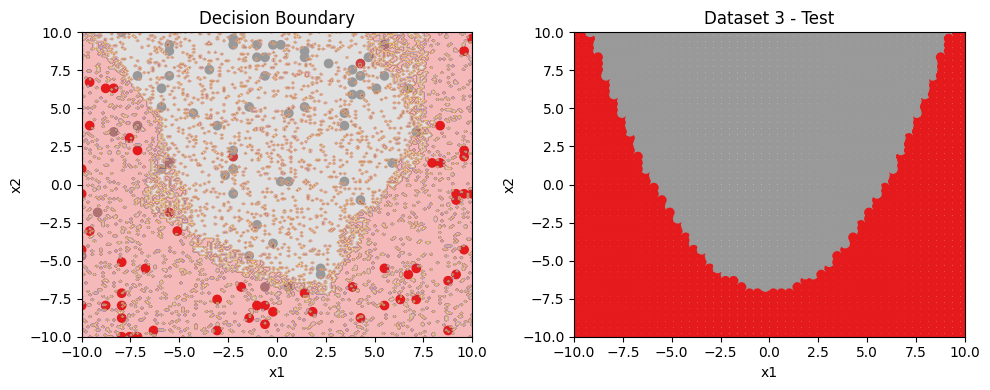

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

model_visualizer.plot(ax1, trainset3, crazynet)
ax1.set_xlim(-10, 10)
ax1.set_ylim(-10, 10)
ax1.set_title("Decision Boundary")

data_visualizer.plot(ax2, testset3)
ax2.set_xlim(-10, 10)
ax2.set_ylim(-10, 10)
ax2.set_title("Dataset 3 - Test")

plt.tight_layout()
plt.show()

# Task 2

- Design your own eccentric model. It doesn't have to perform well, just be creative.
- Train the model on `train3.csv`.
- Predict its performance before testing.
- Analyze its performance on `test3.csv`.
- Explain whether your prediction matched and if not, then why not.


In [88]:
import torch
import torch.nn as nn


class Parasite(nn.Module):
    def __init__(self, hidden):
        super().__init__()

        self.control = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, hidden * 2)
        )

    def forward(self, x):

        control = self.control(x)

        scale, bias = control.chunk(2, dim=1)

        return scale, bias



class ParasiteNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.n_classes = 2
        self.n_features = 2


        # Host network
        self.layer1 = nn.Linear(2, 32)
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 2)


        # parasite living inside layer1
        self.parasite = Parasite(32)



    def forward(self, x):

        # host computation
        h = self.layer1(x)


        # parasite observes input
        scale, bias = self.parasite(x)


        # parasite modifies host neurons
        h = h * (1 + scale) + bias


        h = torch.relu(h)


        h = torch.relu(self.layer2(h))


        scores = self.output(h)


        return scores

Write your prediction with explanation in this cell.

In [89]:
# WRITE YOUR CODE HERE
parasitenet = ParasiteNet()

x, y = next(iter(testloader3))

print(x)
print(y)


tensor([[ 9.1837,  1.4286],
        [-4.2857, -1.0204],
        [-4.2857, -1.4286],
        [ 5.1020,  8.3673],
        [ 5.1020,  2.2449],
        [-2.6531, -4.6939],
        [ 3.4694,  2.6531],
        [-8.3673,  9.5918]])
tensor([0, 1, 1, 1, 1, 1, 1, 1])


In [90]:
scores = parasitenet(x)

print(scores)


tensor([[ 0.6765, -0.2301],
        [-0.4508, -0.0315],
        [-0.5054,  0.0208],
        [ 0.3590,  1.2100],
        [ 0.1481,  0.1353],
        [-0.6164,  0.5480],
        [ 0.0630,  0.1750],
        [ 0.8198, -1.2013]], grad_fn=<AddmmBackward0>)


In [91]:
analyzer = AccuracyAnalyzer()

acc = analyzer.test(
    parasitenet,
    testloader3
)

print(f"{acc*100:.3f}%")

60.480%


In [92]:
y_hat = torch.argmax(scores, dim=-1)

print(y_hat)

tensor([0, 1, 1, 1, 0, 1, 1, 0])


In [93]:
run_gradient_descent(
    model=parasitenet,
    trainloader=trainloader3,
    num_epochs=1000,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

In [94]:
x, y = next(iter(testloader3))

scores = parasitenet(x)

print(scores)

y_hat = torch.argmax(scores, dim=-1)

print(y_hat)


acc = analyzer.test(
    parasitenet,
    testloader3
)

print(f"{acc*100:.3f}%")

tensor([[ 16.3952, -13.6373],
        [ -1.4973,   2.5019],
        [ -0.5626,   1.4314],
        [ -0.9955,   1.1456],
        [ -6.9279,   7.4071],
        [  0.3824,  -0.2313],
        [ -6.8257,   6.8332],
        [-12.2336,   8.4923]], grad_fn=<AddmmBackward0>)
tensor([0, 1, 1, 1, 1, 0, 1, 1])
92.840%


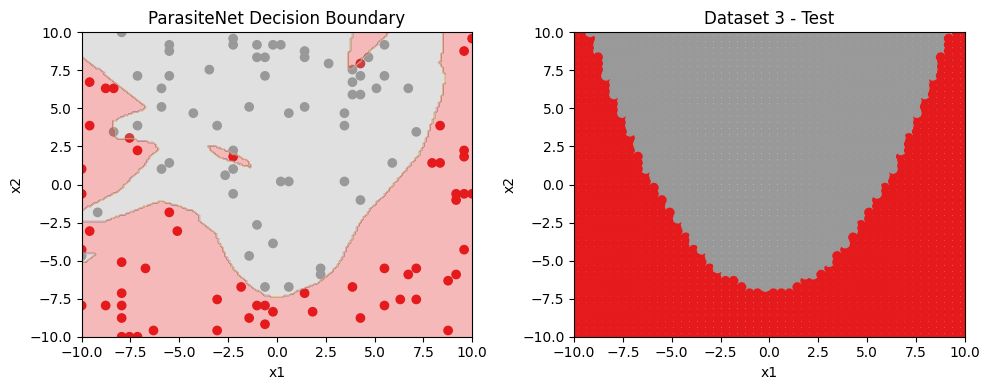

In [95]:
fig, (ax1, ax2) = plt.subplots(
    1,2,
    figsize=(10,4)
)


model_visualizer.plot(
    ax1,
    trainset3,
    parasitenet
)

ax1.set_xlim(-10,10)
ax1.set_ylim(-10,10)
ax1.set_title("ParasiteNet Decision Boundary")


data_visualizer.plot(
    ax2,
    testset3
)

ax2.set_xlim(-10,10)
ax2.set_ylim(-10,10)
ax2.set_title("Dataset 3 - Test")


plt.tight_layout()
plt.show()

The Parasite Neural Network introduces a secondary network that controls the internal behavior of a main prediction network. The parasite observes the input and modifies hidden layer activations by scaling and shifting neuron outputs, allowing the host network to dynamically adjust its features. Both networks are trained together through backpropagation, enabling the parasite to learn useful modifications that improve prediction. The results show that the model can create flexible decision boundaries and adapt its internal representation better than a fixed neural network. However, strong parasite influence may cause instability, so the modulation strength needs to be controlled. Overall, the network demonstrates a self-adjusting architecture where one neural network improves another during learning.


# Import Torchvision

In [58]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

# CIFAR10 Dataset

`torchvision.datasets.CIFAR10` loads the CIFAR-10 image classification dataset. CIFAR-10 contains 60,000 color images from 10 classes, with 50,000 training images and 10,000 test images. Each image has shape `3 x 32 x 32` after `transforms.ToTensor()` converts it to a PyTorch tensor.

Common arguments:

1. `root`: directory where the dataset is stored.
2. `train`: `True` loads the training split; `False` loads the test split.
3. `download`: downloads the dataset if it is not already present.
4. `transform`: function applied to each image. Here, `transforms.ToTensor()` converts PIL images to float tensors in `[0, 1]`.

Useful attributes and methods:

1. `classes`: list of class names.
2. `__len__()`: returns the number of images in the selected split.
3. `__getitem__(idx)`: returns `(image, label)` for one index.

When wrapped in a `DataLoader`, each batch contains image tensors with shape `(batch_size, 3, 32, 32)` and label tensors with shape `(batch_size,)`.

## Load Data

In [59]:
transform = transforms.ToTensor()

cifar10_trainset = torchvision.datasets.CIFAR10(
    root="/content/datasets/CIFAR10",
    train=True,
    download=True,
    transform=transform
)

cifar10_testset = torchvision.datasets.CIFAR10(
    root="/content/datasets/CIFAR10",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


In [60]:
print(f"Trainset size: {len(cifar10_trainset)}")
print(f"Testset size: {len(cifar10_testset)}")

Trainset size: 50000
Testset size: 10000


In [61]:
sample_size = 10000

indices = torch.randperm(len(cifar10_trainset))[:sample_size]
cifar10_train_subset = Subset(cifar10_trainset, indices)

In [62]:
cifar10_trainloader = DataLoader(
    cifar10_train_subset,
    batch_size=64,
    shuffle=True
)

cifar10_testloader = DataLoader(
    cifar10_testset,
    batch_size=64,
    shuffle=False
)

In [63]:
class_images = [None] * 10

for x, y in cifar10_testset:
    if class_images[y] is None: class_images[y] = x
    if all(x is not None for x in class_images): break

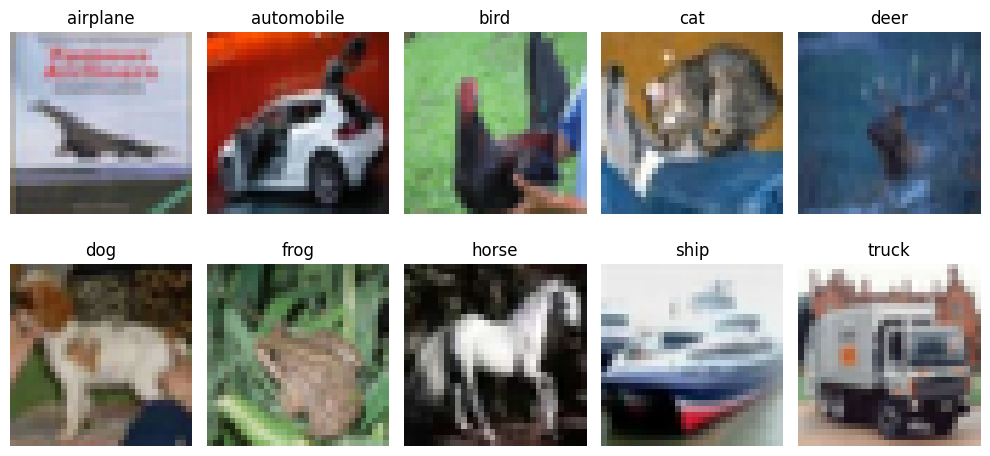

In [64]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = class_images[i]
    img = img.permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(cifar10_testset.classes[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Weight Visualizer for Linear Classifiers

## `WeightVisualizer`
`WeightVisualizer` displays the learned weight vector for one class of a linear image classifier as an image. For CIFAR-10, each class weight has 3072 values, which can be reshaped into `3 x 32 x 32`.

Attributes:

1. `img_shape`: target image shape used when reshaping one class's weight vector.
2. `cmap`: optional Matplotlib color map.

Methods:

1. `__init__(self, img_shape=(3, 32, 32), cmap=None)`: stores the expected image shape and color map.
2. `_normalize(self, img)`: rescales an image array to `[0, 1]` for display. It returns the normalized image.
3. `plot(self, ax, model, class_idx, title=None)`: extracts `model.w[class_idx]`, reshapes it into an image, normalizes it, draws it on the supplied axis, sets a title, and returns the axis.

Return value: `plot` returns the Matplotlib axis that was passed in.

In [65]:
class WeightVisualizer:
    def __init__(self, img_shape=(3, 32, 32), cmap=None):
        self.img_shape = img_shape
        self.cmap = cmap

    def _normalize(self, img):
        img = img - img.min()
        img = img / (img.max() + EPS)
        return img

    def plot(self, ax, model, class_idx, title=None):
        W = model.w.detach().cpu().numpy()

        img = W[class_idx].reshape(self.img_shape)
        img = self._normalize(img)
        img = np.transpose(img, (1, 2, 0))

        ax.imshow(img)
        ax.axis("off")

        if title is None: title = f"class {class_idx} weights"
        ax.set_title(title)

        return ax

In [66]:
weight_visualizer = WeightVisualizer()

# Example 4

## Prepare Model

In [67]:
linear_classifier3 = LinearClassifier(
    n_features=3072,
    n_classes=10,
    sigma=1/3072
)

## Train Model

In [68]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(linear_classifier3, cifar10_testloader)
print(f"{acc * 100:.3f}%")

10.000%


In [69]:
run_gradient_descent(
    model=linear_classifier3,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

## Analyze Results

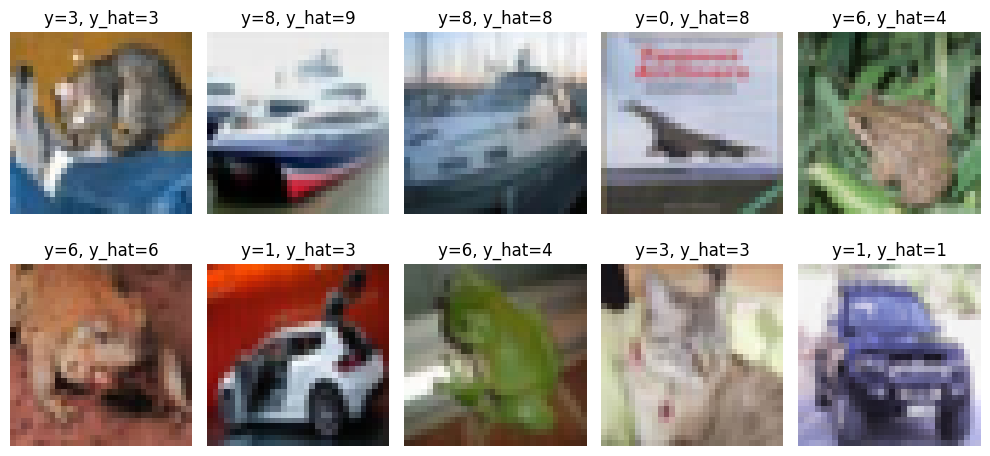

In [70]:
x, y = next(iter(cifar10_testloader))
scores = linear_classifier3(x)
y_hat = torch.argmax(scores, dim=-1)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = x[i].permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(f"y={y[i].item()}, y_hat={y_hat[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [71]:
analyzer = AccuracyAnalyzer()
acc = analyzer.test(linear_classifier3, cifar10_testloader)
print(f"Accuracy: {acc * 100:.3f}%")

Accuracy: 34.150%


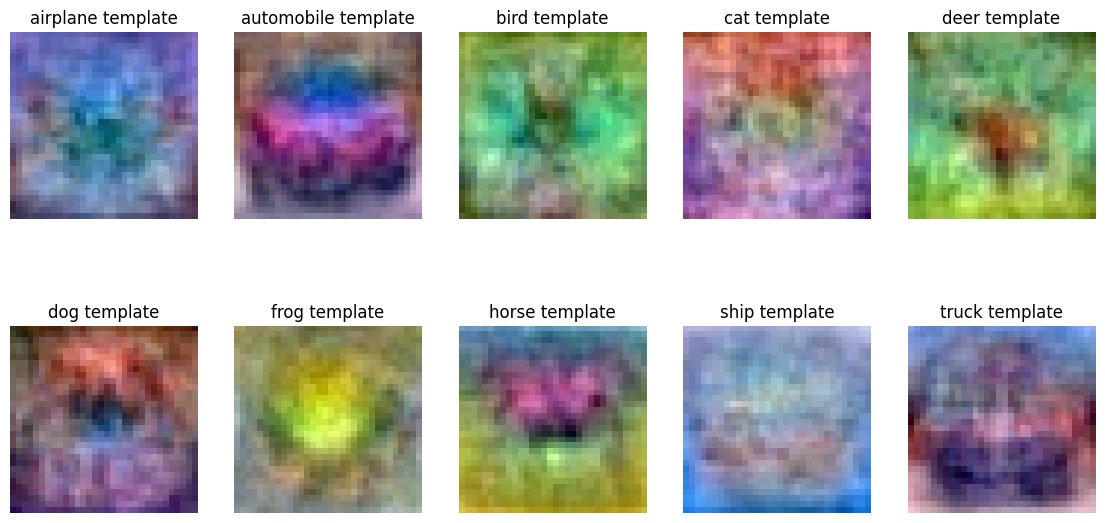

In [72]:
fig, axes = plt.subplots(2, 5, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    weight_visualizer.plot(
        ax,
        linear_classifier3,
        class_idx=i,
        title=f"{cifar10_testset.classes[i]} template"
    )

# Optimization

Optimization controls how model parameters are updated after gradients are computed. The previous training loop used plain gradient descent, where each parameter moves directly opposite its gradient. The remaining sections compare more advanced update rules that use accumulated gradient information to change the update direction or step size.

## SGD with Momentum

### `run_sgd`
`run_sgd` trains a PyTorch model with stochastic gradient descent plus momentum. Momentum keeps a running velocity for each parameter, which helps updates continue in consistent directions and reduces oscillation.

Arguments:

1. `model`: PyTorch model to train.
2. `trainloader`: loader that yields `(x, y)` mini-batches.
3. `num_epochs`: number of passes over the training loader.
4. `loss_fn`: loss function that returns a scalar loss tensor.
5. `alpha`: learning rate.
6. `beta`: momentum coefficient. Larger values keep more of the previous velocity.

Internal attributes:

1. `epoch_losses`: list of average training losses, one per epoch.
2. `velocity`: dictionary mapping each parameter to its momentum buffer.

Return value: none. The function updates model parameters in place and plots the loss curve.

In [73]:
def run_sgd(model, trainloader, num_epochs, loss_fn, alpha, rho):
    epoch_losses = []

    velocity = {
        param: torch.zeros_like(param)
        for param in model.parameters()
    }

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            scores = model(x)
            batch_loss = loss_fn(scores, y)

            for param in model.parameters(): param.grad = None
            batch_loss.backward()

            with torch.no_grad():
                for param in model.parameters():
                    if param.grad is not None:
                        velocity[param] = rho * velocity[param] + param.grad
                        param -= alpha * velocity[param]

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)
        epoch_losses.append(epoch_loss)

    plt.plot(range(1, num_epochs + 1), epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

# Example 5

## Prepare Model

In [74]:
linear_classifier4 = LinearClassifier(
    n_features=3072,
    n_classes=10,
    sigma=1/3072
)

## Train Model

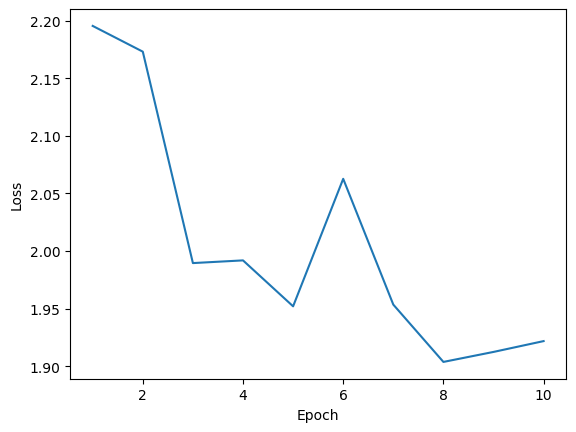

In [75]:
run_sgd(
    model=linear_classifier4,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
    rho=0.9
)

# Task 3

Write training functions for AdaGrad, RMSProp, and Adam optimizer and compare the loss curves.

Expected function behavior:

1. AdaGrad should accumulate squared gradients and scale each parameter update by the inverse square root of that accumulator.
2. RMSProp should use an exponential moving average of squared gradients instead of an ever-growing sum.
3. Adam should maintain exponential moving averages of both gradients and squared gradients, apply bias correction, and then update parameters.

Each function should accept a model, train loader, number of epochs, loss function, and optimizer hyperparameters. Each function should update the model in place and record or plot average loss per epoch.

In [76]:
# WRITE YOUR CODE HERE
import torch
import matplotlib.pyplot as plt

def run_ada(model, trainloader, num_epochs, loss_fn, alpha=0.01, eps=1e-8):
    epoch_losses = []

    # Accumulated squared gradients
    G = {
        param: torch.zeros_like(param)
        for param in model.parameters()
    }

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            scores = model(x)
            batch_loss = loss_fn(scores, y)

            for param in model.parameters():
                param.grad = None

            batch_loss.backward()

            with torch.no_grad():
                for param in model.parameters():
                    if param.grad is not None:
                        # Accumulate squared gradients
                        G[param] += param.grad ** 2

                        # AdaGrad update
                        adjusted_lr = alpha / (torch.sqrt(G[param]) + eps)
                        param -= adjusted_lr * param.grad

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)
        epoch_losses.append(epoch_loss)

    plt.plot(range(1, num_epochs + 1), epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("AdaGrad Training Loss")
    plt.show()

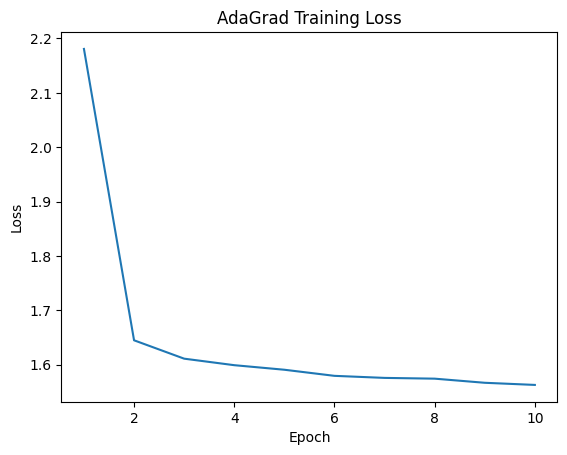

In [77]:
run_ada(
    model=linear_classifier4,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

In [96]:
import torch
import matplotlib.pyplot as plt


def run_rmsprop(model, trainloader, num_epochs, loss_fn, alpha=0.001, beta=0.9, eps=1e-8):

    epoch_losses = []

    # Exponential moving average of squared gradients
    E = {
        param: torch.zeros_like(param)
        for param in model.parameters()
    }


    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0.0


        for x, y in trainloader:

            scores = model(x)

            batch_loss = loss_fn(scores, y)


            for param in model.parameters():
                param.grad = None


            batch_loss.backward()


            with torch.no_grad():

                for param in model.parameters():

                    if param.grad is not None:

                        # moving average of squared gradients
                        E[param] = beta * E[param] + (1 - beta) * param.grad ** 2


                        # RMSProp update
                        adjusted_lr = alpha / (torch.sqrt(E[param]) + eps)

                        param -= adjusted_lr * param.grad


            epoch_loss += batch_loss.item()


        epoch_loss /= len(trainloader)

        epoch_losses.append(epoch_loss)



    plt.plot(range(1, num_epochs + 1), epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("RMSProp Training Loss")
    plt.show()

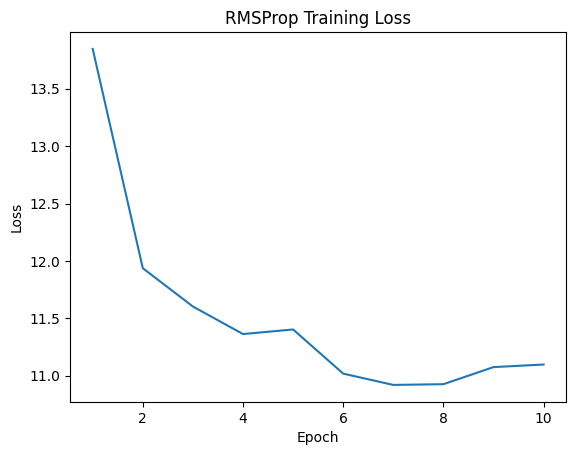

In [97]:
run_rmsprop(
    model=linear_classifier4,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

In [99]:
import torch
import matplotlib.pyplot as plt


def run_adam(model, trainloader, num_epochs, loss_fn, alpha=0.001,
             beta1=0.9, beta2=0.999, eps=1e-8):


    epoch_losses = []


    # first moment (gradient)
    M = {
        param: torch.zeros_like(param)
        for param in model.parameters()
    }


    # second moment (squared gradient)
    V = {
        param: torch.zeros_like(param)
        for param in model.parameters()
    }


    t = 0



    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0.0


        for x, y in trainloader:


            scores = model(x)

            batch_loss = loss_fn(scores, y)


            for param in model.parameters():
                param.grad = None


            batch_loss.backward()


            t += 1


            with torch.no_grad():

                for param in model.parameters():

                    if param.grad is not None:


                        # update first moment
                        M[param] = beta1 * M[param] + (1 - beta1) * param.grad


                        # update second moment
                        V[param] = beta2 * V[param] + (1 - beta2) * param.grad ** 2



                        # bias correction
                        M_hat = M[param] / (1 - beta1 ** t)

                        V_hat = V[param] / (1 - beta2 ** t)



                        # Adam update
                        param -= alpha * M_hat / (torch.sqrt(V_hat) + eps)



            epoch_loss += batch_loss.item()



        epoch_loss /= len(trainloader)

        epoch_losses.append(epoch_loss)



    plt.plot(range(1, num_epochs + 1), epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Adam Training Loss")
    plt.show()

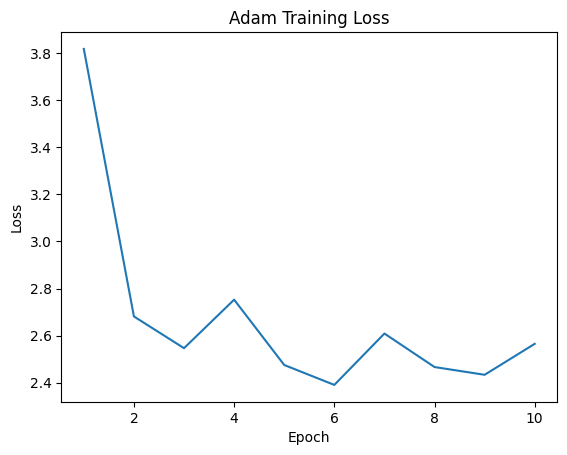

In [100]:
run_adam(
    model=linear_classifier4,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    alpha=0.01,
)

This task implements and compares AdaGrad, RMSProp, and Adam optimizers by creating custom training functions that update model parameters and record loss per epoch. AdaGrad adapts learning rates using accumulated squared gradients, RMSProp uses an exponential moving average of squared gradients for more stable updates, and Adam combines gradient momentum with adaptive learning rates using bias correction. The loss curves are used to analyze convergence behavior, where AdaGrad provides quick initial learning but may slow down, RMSProp improves stability, and Adam generally achieves faster and smoother convergence due to its combined optimization approach.


# Optimizers

PyTorch optimizer classes, such as `torch.optim.SGD`, `torch.optim.RMSprop`, and `torch.optim.Adam`, package parameter-update rules so the training loop does not need to manually edit each parameter.

Typical optimizer methods:

1. `zero_grad()`: clears old gradients from all parameters managed by the optimizer.
2. `step()`: updates the managed parameters using their current gradients and the optimizer's internal state.
3. `state_dict()`: returns optimizer state, including momentum buffers or adaptive learning-rate accumulators.
4. `load_state_dict(state)`: restores a saved optimizer state.

### `run_gradient_descent_optimizer`
`run_gradient_descent_optimizer` trains a PyTorch model using a supplied optimizer object.

Arguments:

1. `model`: PyTorch model to train.
2. `trainloader`: loader that yields mini-batches.
3. `num_epochs`: number of training epochs.
4. `loss_fn`: loss function that returns a scalar tensor.
5. `optimizer`: PyTorch optimizer already constructed with `model.parameters()`.

Behavior: for each batch, the function computes scores and loss, calls `optimizer.zero_grad()`, runs `batch_loss.backward()`, then calls `optimizer.step()`.

Return value: none. The function updates the model in place and plots the average loss per epoch.

In [78]:
def run_gradient_descent_optimizer(
    model,
    trainloader,
    num_epochs,
    loss_fn,
    optimizer,
):
    epoch_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            scores = model(x)
            batch_loss = loss_fn(scores, y)

            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)
        epoch_losses.append(epoch_loss)

    plt.plot(range(1, num_epochs + 1), epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

# Example 6

## Prepare Model

In [79]:
linear_classifier8 = LinearClassifier(
    n_features=3072,
    n_classes=10,
    sigma=1/3072
)

## Prepare Optimizer

In [80]:
optimizer = torch.optim.Adam(
    linear_classifier8.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
)

## Train Model

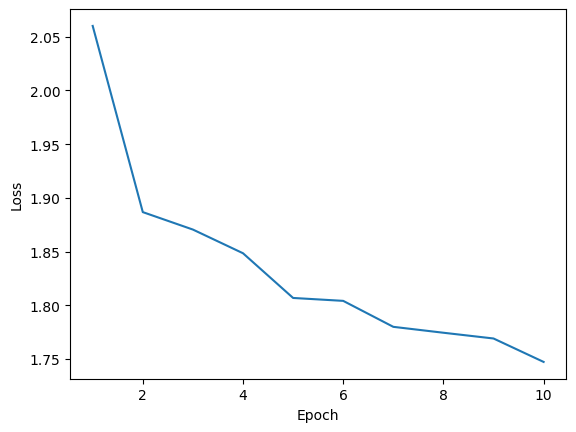

In [81]:
run_gradient_descent_optimizer(
    model=linear_classifier8,
    trainloader=cifar10_trainloader,
    num_epochs=10,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=optimizer,
)